Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Libraries imported
✅ Plots will save to: /content/drive/MyDrive/Datasets/EDA Plots
✅ Helpers defined

  LOADING: MLR Part3 — All Years
  ✅ MLR-2019: (98838, 42)
  ✅ MLR-2020: (92167, 42)
  ✅ MLR-2021: (93499, 42)
  ✅ MLR_2018: (106324, 42)
  ✅ mlr-2022: (91908, 42)
  ✅ mlr-2023: (85211, 42)
  ✅ mlr-2024: (81178, 42)

  Combined MLR Part3: (649125, 83)
  ✅ MLR Ratio from individual market CY/Total

  LOADING: Landscape 2023 (county geography)
  ✅ Landscape 2023: (134912, 6)
  States: 33
  Counties: 2449

  LOADING: County-Level Datasets
  ✅ CDC SVI: (3144, 158)
  ✅ CDC PLACES: (3143, 167)
  ✅ HUD Crosswalk: (54553, 8)
  ✅ HRSA Geo: (3240, 57)

  LOADING: CFPB Complaints (chunked, health only)
  Processed 1,000,000 rows so far...
  Processed 2,000,000 rows so far...
  Processed 3,000,000 rows so far...
  Processed 4,000,000 rows so far...
  Processed 5,000,00

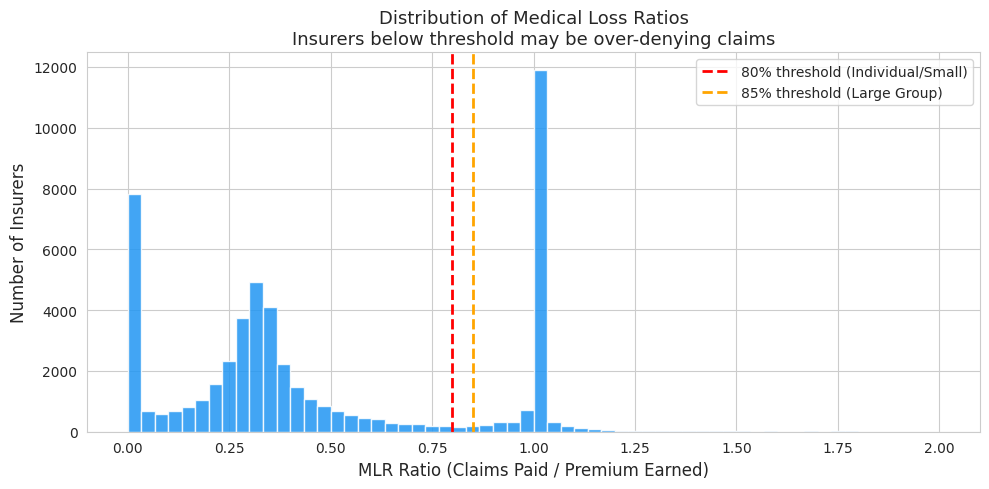

  ✅ Saved: Q1_01_mlr_distribution.png
[Q1-2] MLR Trend by Year...


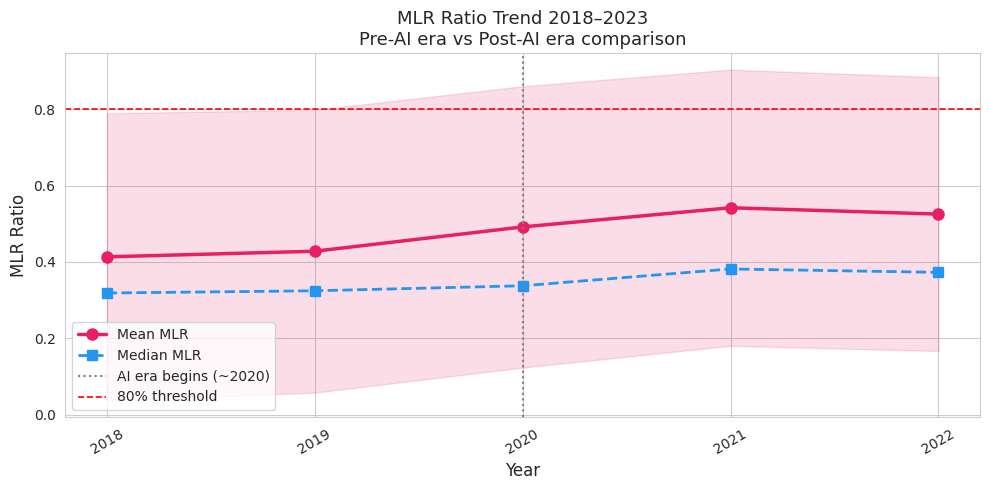

  ✅ Saved: Q1_02_mlr_trend_by_year.png
[Q1-3] Below-threshold count by year...


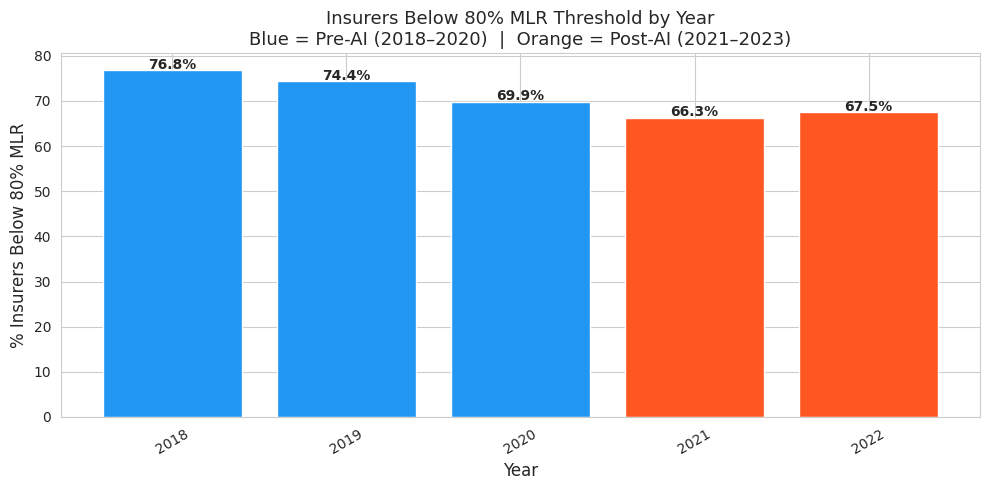

  ✅ Saved: Q1_03_below_threshold_by_year.png
[Q1-4] Plan availability by state...


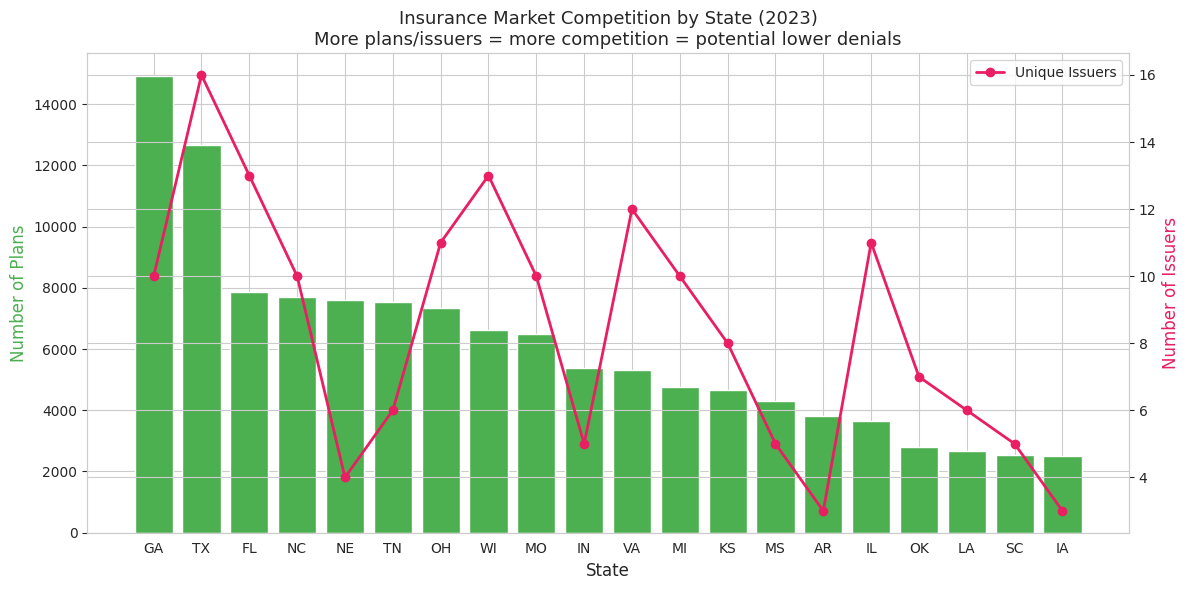

  ✅ Saved: Q1_04_market_competition_by_state.png

[Q2-1] SVI Distribution...


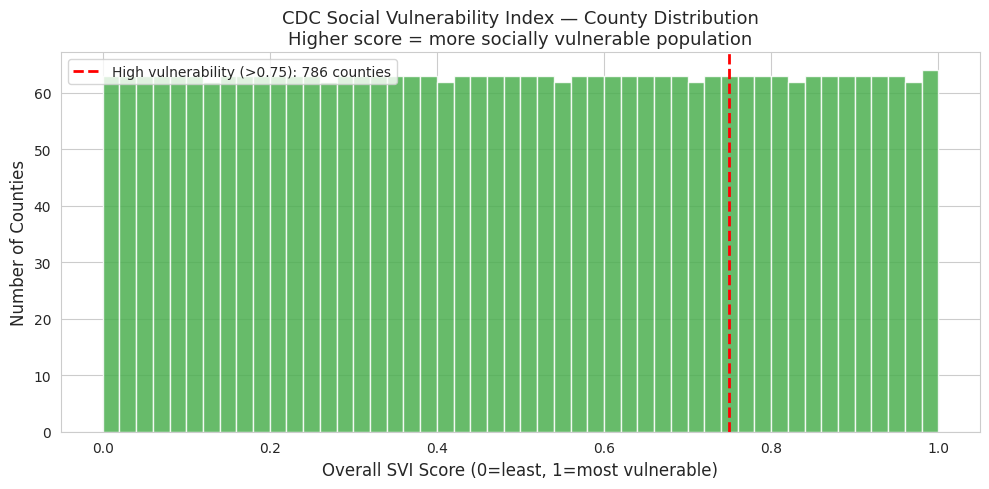

  ✅ Saved: Q2_01_svi_distribution.png
[Q2-2] SVI vs Uninsured...


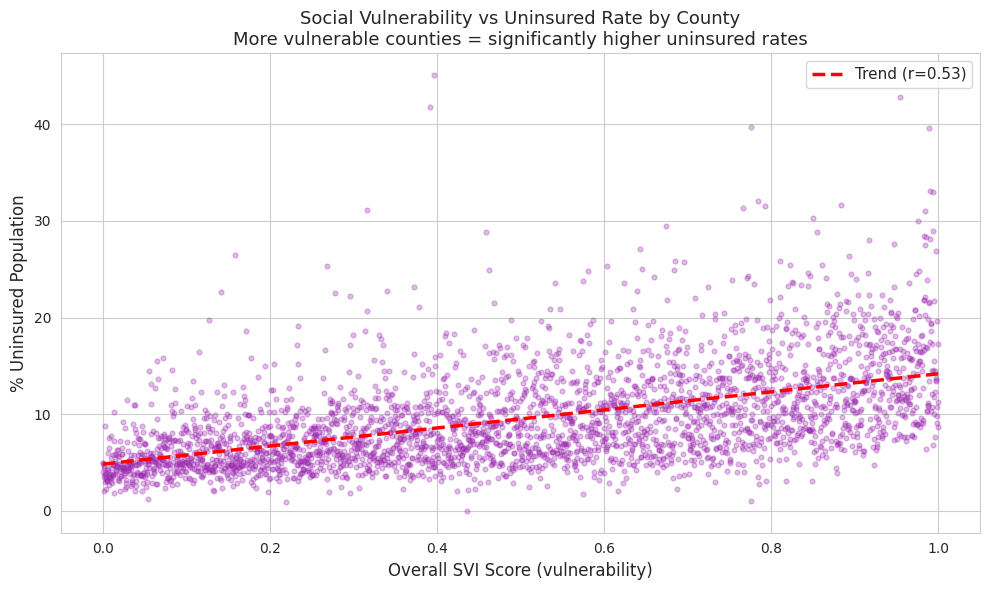

  ✅ Saved: Q2_02_svi_vs_uninsured.png
[Q2-3] SVI Themes Correlation...


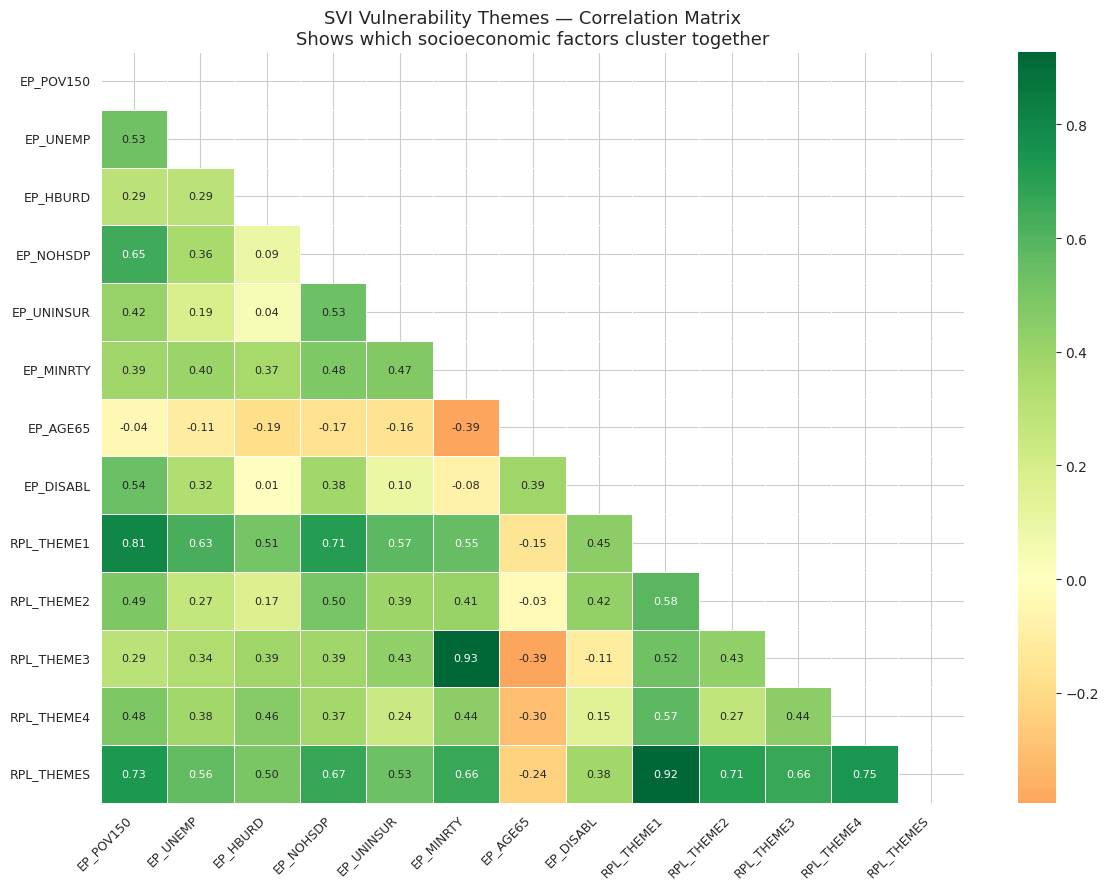

  ✅ Saved: Q2_03_svi_correlation_heatmap.png
[Q2-4] CFPB Complaints by State...


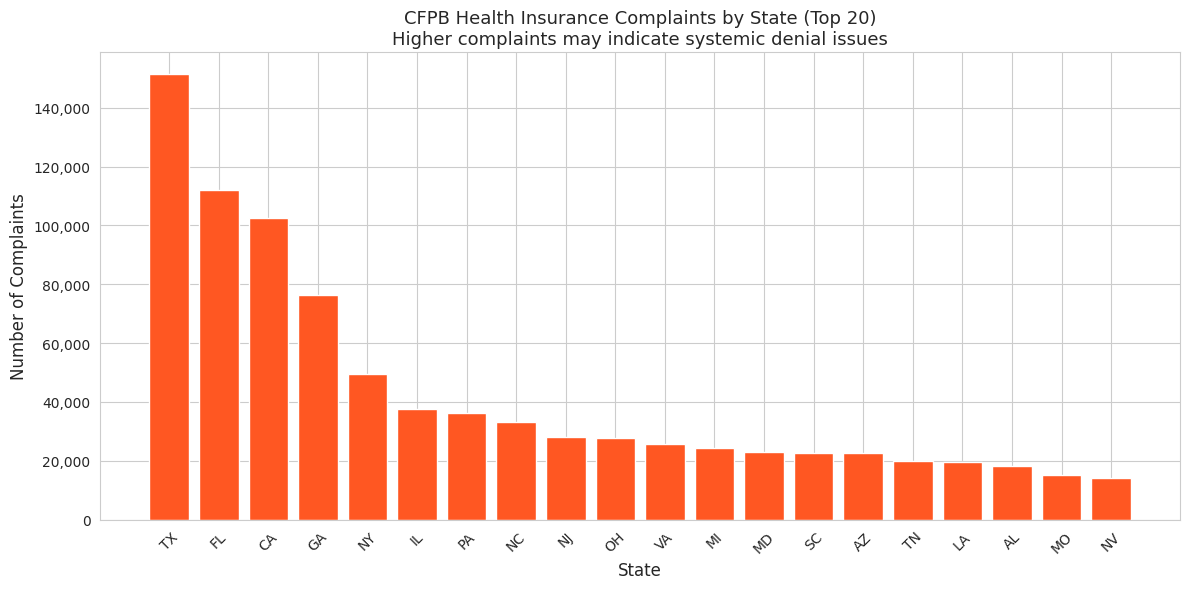

  ✅ Saved: Q2_04_cfpb_complaints_by_state.png
[Q2-5] CFPB Trend by Year...


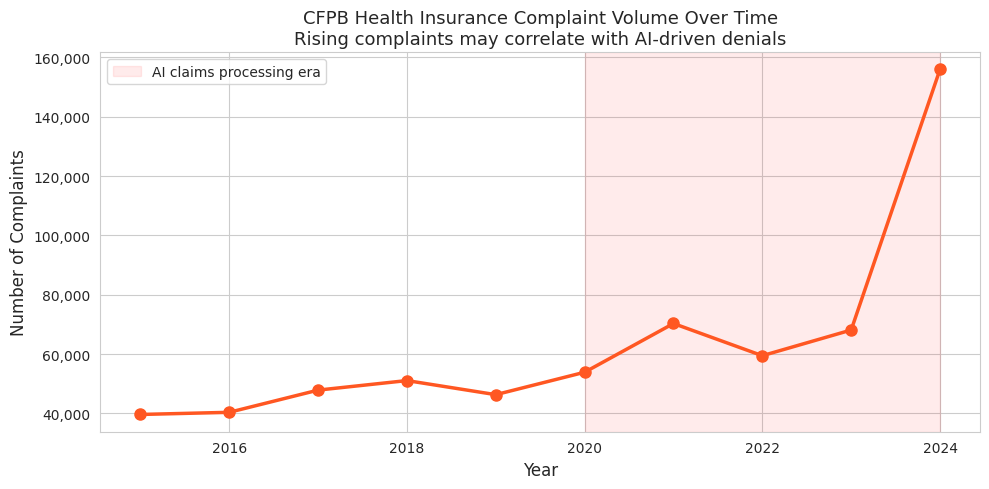

  ✅ Saved: Q2_05_cfpb_trend_by_year.png
[Q2-6] CFPB Top Issues...


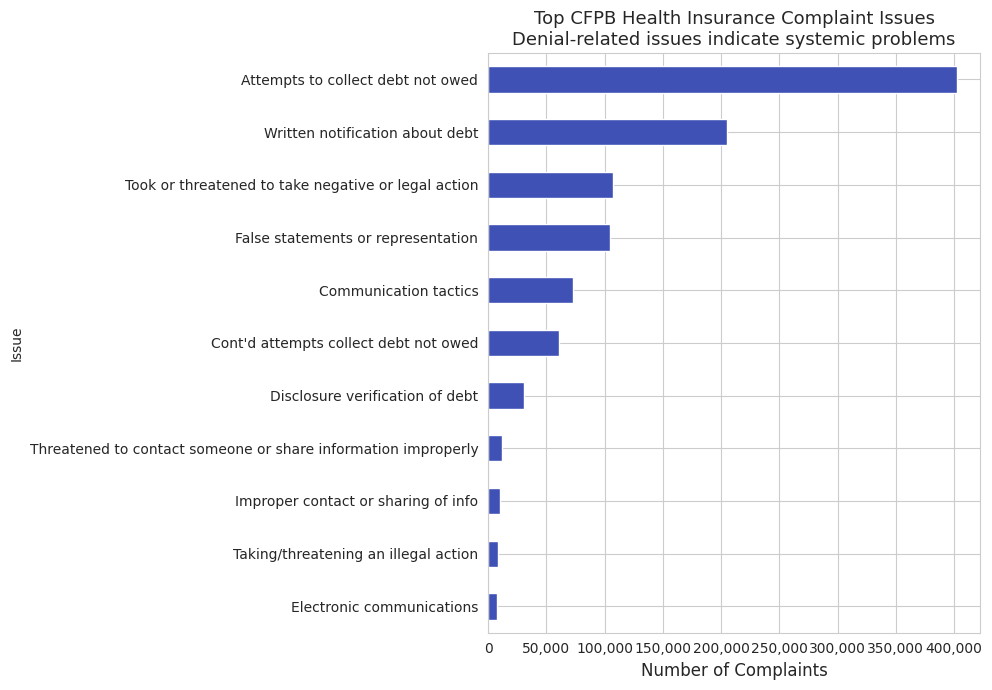

  ✅ Saved: Q2_06_cfpb_top_issues.png
[Q2-7] Health Outcomes by Vulnerability...


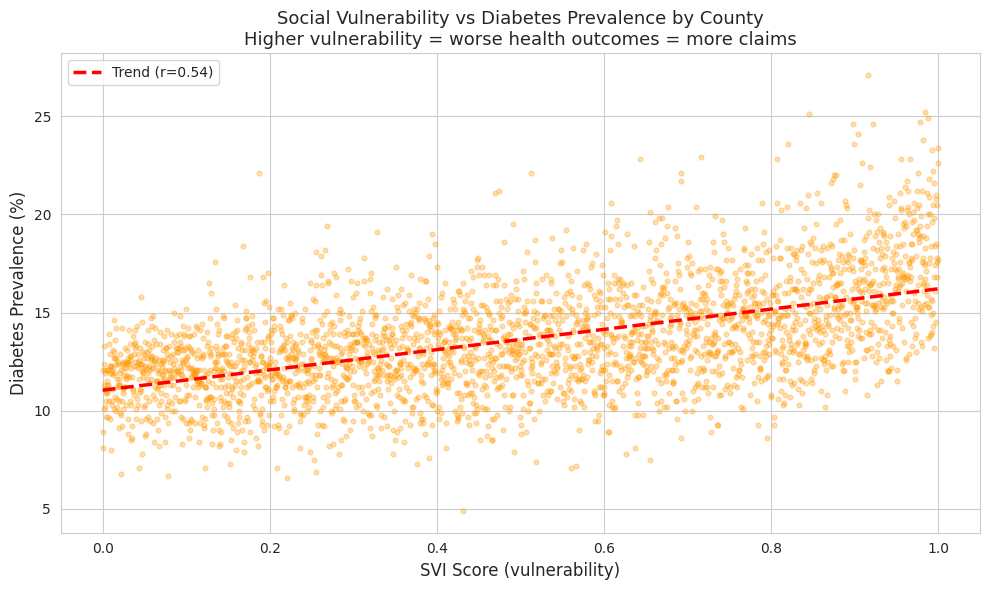

  ✅ Saved: Q2_07_vulnerability_vs_diabetes.png

[Q3-1] Race Distribution...


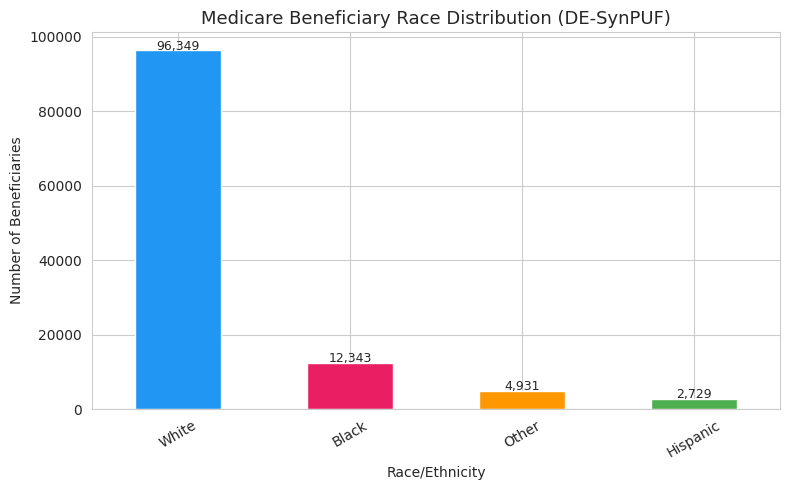

  ✅ Saved: Q3_01_race_distribution.png
[Q3-2] Denial Rate by Race...


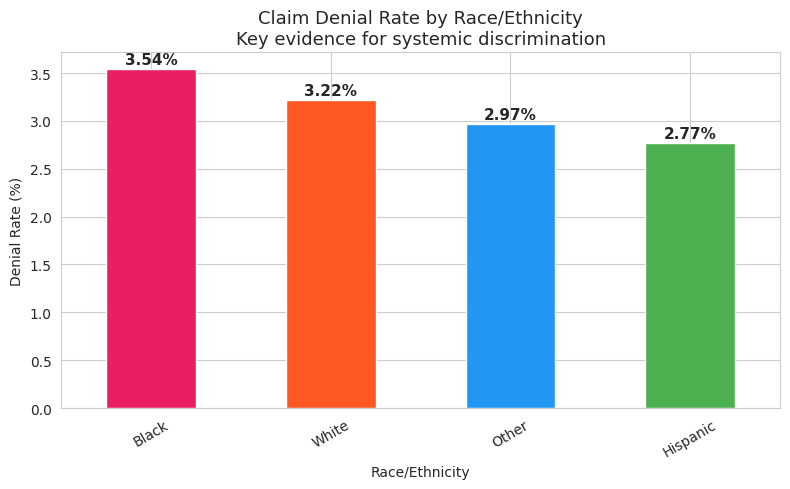

  ✅ Saved: Q3_02_denial_rate_by_race.png
[Q3-3] Denial Rate by Chronic Condition...


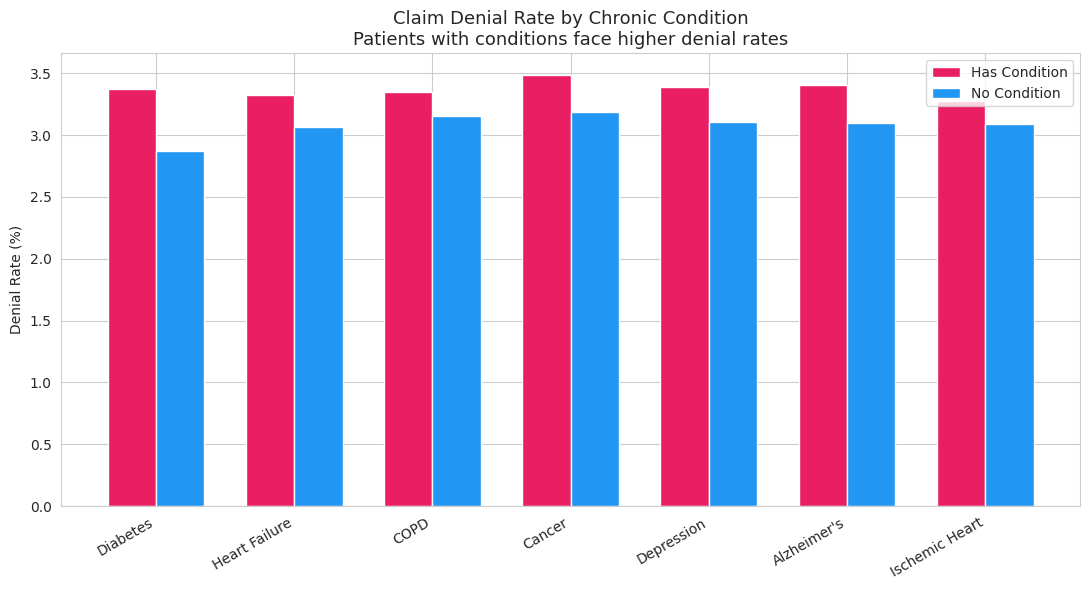

  ✅ Saved: Q3_03_denial_by_condition.png
[Q3-4] Payment Distribution...


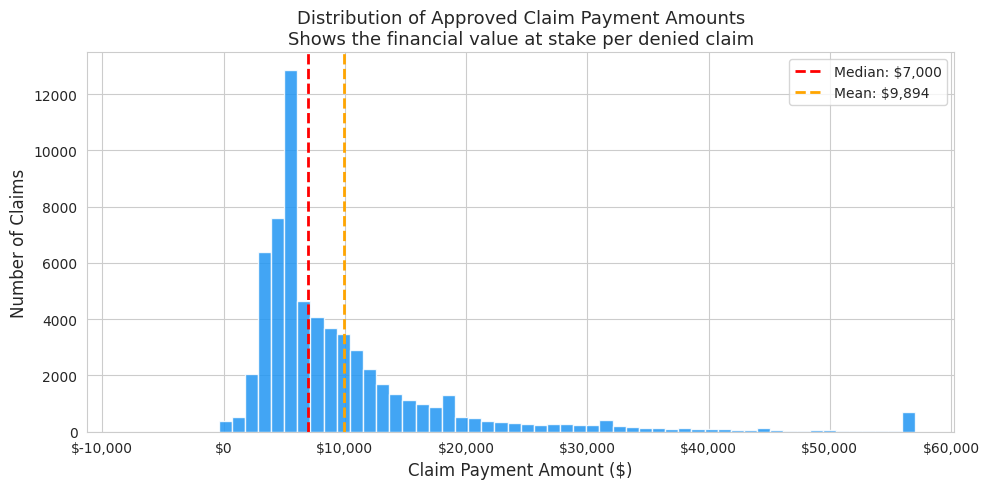

  ✅ Saved: Q3_04_payment_distribution.png
[Q3-5] Denial Rate by Age Group...


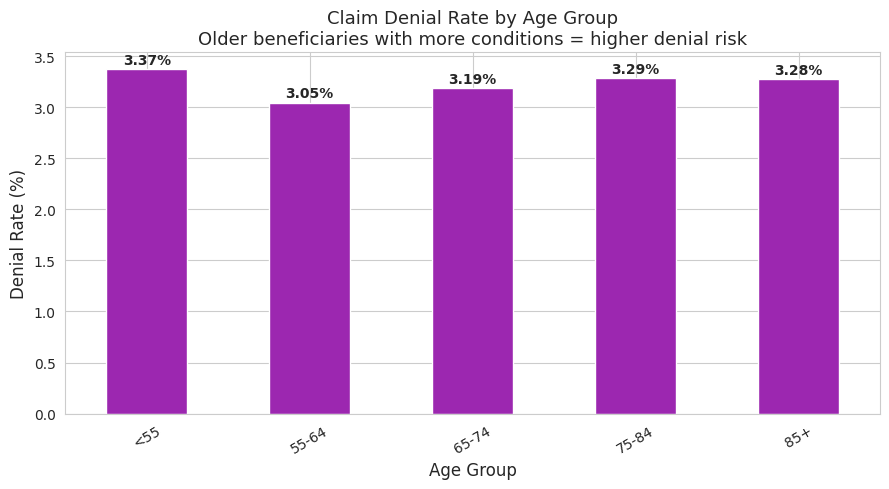

  ✅ Saved: Q3_05_denial_by_age_group.png
[Q3-6] Denial Rate by Sex...


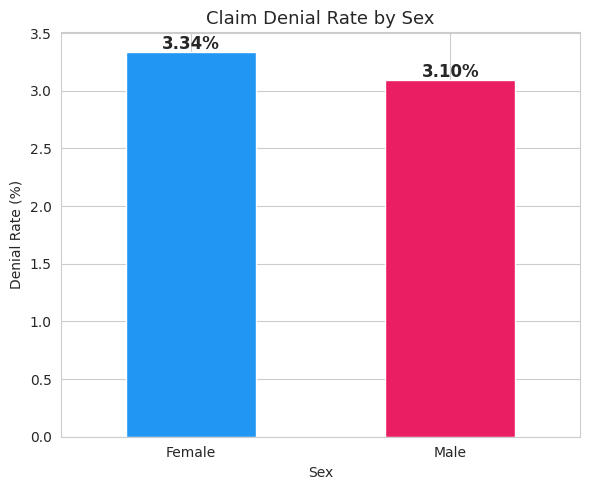

  ✅ Saved: Q3_06_denial_by_sex.png
[Q3-7] Condition Burden vs Denial Rate...


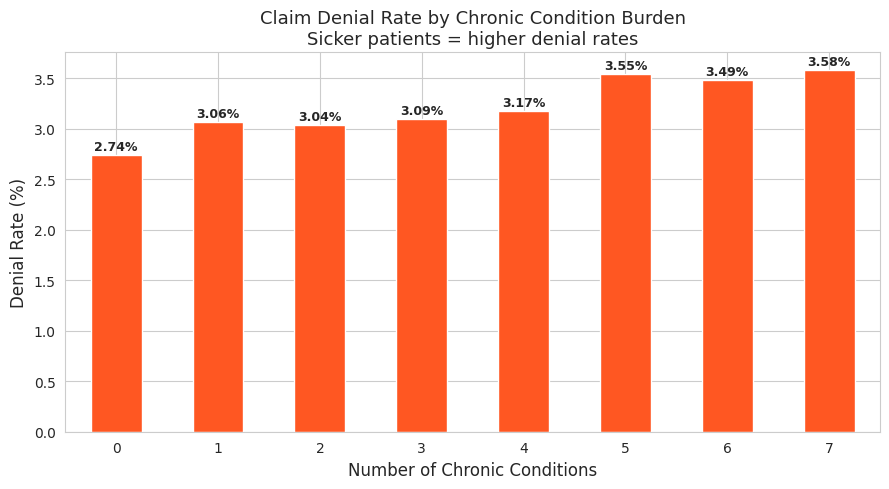

  ✅ Saved: Q3_07_denial_by_condition_burden.png

  ✅ ALL PLOTS GENERATED & SAVED TO DRIVE

  📊 Total plots saved: 18
    Q1_01_mlr_distribution.png
    Q1_02_mlr_trend_by_year.png
    Q1_03_below_threshold_by_year.png
    Q1_04_market_competition_by_state.png
    Q2_01_svi_distribution.png
    Q2_02_svi_vs_uninsured.png
    Q2_03_svi_correlation_heatmap.png
    Q2_04_cfpb_complaints_by_state.png
    Q2_05_cfpb_trend_by_year.png
    Q2_06_cfpb_top_issues.png
    Q2_07_vulnerability_vs_diabetes.png
    Q3_01_race_distribution.png
    Q3_02_denial_rate_by_race.png
    Q3_03_denial_by_condition.png
    Q3_04_payment_distribution.png
    Q3_05_denial_by_age_group.png
    Q3_06_denial_by_sex.png
    Q3_07_denial_by_condition_burden.png

  📁 Location: /content/drive/MyDrive/Datasets/EDA Plots

  Go to Google Drive → Datasets → EDA Plots to view all plots

  DATASET READINESS SUMMARY

  Dataset                            Rows   Cols  Status
  ---------------------------------------------------

In [ ]:
"""
=============================================================
 Healthcare Insurance Claim Denials — FULL EDA v3
=============================================================
 RAM-safe version with:
  - Chunked CFPB loading (8GB file handled safely)
  - All plots saved DIRECTLY to Google Drive
  - All 15 EDA plots across Q1, Q2, Q3
  - County merge pipeline
=============================================================
"""

# ─────────────────────────────────────────────
# CELL 1 — MOUNT & IMPORTS
# ─────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

BASE_PATH = "/content/drive/MyDrive/Datasets"
PLOT_DIR  = "/content/drive/MyDrive/Datasets/EDA Plots"
os.makedirs(PLOT_DIR, exist_ok=True)

print("✅ Libraries imported")
print(f"✅ Plots will save to: {PLOT_DIR}")


# ─────────────────────────────────────────────
# CELL 2 — HELPER FUNCTIONS
# ─────────────────────────────────────────────
def save_plot(filename, title=""):
    path = os.path.join(PLOT_DIR, filename)
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  ✅ Saved: {filename}")

def standardize_fips(df, col):
    df = df.copy()
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=[col])
    df[col] = df[col].astype(int).astype(str).str.zfill(5)
    return df

def quick_profile(df, name):
    if df.empty:
        print(f"  ⚠️  {name} is empty")
        return
    null_pct = (df.isnull().mean()*100).round(1)
    high = null_pct[null_pct > 20]
    print(f"\n  {name}: {df.shape[0]:,} rows × {df.shape[1]} cols")
    if not high.empty:
        print(f"  ⚠️  {len(high)} columns >20% null")
    else:
        print(f"  ✅ No columns >20% null")

print("✅ Helpers defined")


# ─────────────────────────────────────────────
# CELL 3 — LOAD MLR PART3 (Q1) — ALL YEARS
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("  LOADING: MLR Part3 — All Years")
print("="*55)

mlr_years = []
mlr_base  = os.path.join(BASE_PATH, "MLR Denial Data")

for subfolder in sorted(os.listdir(mlr_base)):
    if subfolder.startswith('.'): continue
    sub_path = os.path.join(mlr_base, subfolder)
    if not os.path.isdir(sub_path): continue
    for f in os.listdir(sub_path):
        if "Part3" in f and f.endswith(".csv") and "Notes" not in f:
            df = pd.read_csv(os.path.join(sub_path, f), low_memory=False)
            df["_year"] = subfolder.replace("MLR_","").replace("MLR-","").replace("mlr-","")
            mlr_years.append(df)
            print(f"  ✅ {subfolder}: {df.shape}")

mlr_part3 = pd.concat(mlr_years, ignore_index=True)
print(f"\n  Combined MLR Part3: {mlr_part3.shape}")

# Find MLR numerator/denominator columns
num_col  = next((c for c in mlr_part3.columns if "MLR_NUM"   in c.upper()), None)
den_col  = next((c for c in mlr_part3.columns if "MLR_DENOM" in c.upper()), None)

# Build MLR ratio from individual market columns if no explicit ratio columns
ind_cy  = next((c for c in mlr_part3.columns
                if "CMM_INDIVIDUAL_CY" == c.upper()), None)
ind_tot = next((c for c in mlr_part3.columns
                if "CMM_INDIVIDUAL_TOTAL" == c.upper()), None)

if num_col and den_col:
    mlr_part3["MLR_RATIO"] = (
        pd.to_numeric(mlr_part3[num_col], errors="coerce") /
        pd.to_numeric(mlr_part3[den_col], errors="coerce")
    )
    print(f"  ✅ MLR Ratio from {num_col} / {den_col}")
elif ind_cy and ind_tot:
    mlr_part3["MLR_RATIO"] = (
        pd.to_numeric(mlr_part3[ind_cy],  errors="coerce") /
        pd.to_numeric(mlr_part3[ind_tot], errors="coerce")
    )
    print(f"  ✅ MLR Ratio from individual market CY/Total")
else:
    # Use CMM_INDIVIDUAL columns — CY = claims, find premium proxy
    cy_cols  = [c for c in mlr_part3.columns if "_CY"    in c.upper() and "CMM" in c.upper()]
    tot_cols = [c for c in mlr_part3.columns if "_TOTAL" in c.upper() and "CMM" in c.upper()]
    print(f"  ⚠️  No explicit MLR cols. CY cols: {cy_cols[:3]}, TOTAL cols: {tot_cols[:3]}")
    if cy_cols and tot_cols:
        mlr_part3["MLR_RATIO"] = (
            pd.to_numeric(mlr_part3[cy_cols[0]],  errors="coerce") /
            pd.to_numeric(mlr_part3[tot_cols[0]], errors="coerce")
        )
        print(f"  ✅ Using {cy_cols[0]} / {tot_cols[0]}")


# ─────────────────────────────────────────────
# CELL 4 — LOAD LANDSCAPE (Q1 county map)
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("  LOADING: Landscape 2023 (county geography)")
print("="*55)

# Row 0 is a garbage summary row, Row 1 is the real header
land = pd.read_excel(
    os.path.join(BASE_PATH, "Landscape", "Individual_Market_Medical-2023.xlsx"),
    header=1,
    usecols=["State Code", "FIPS County Code", "County Name",
             "Issuer Name", "Metal Level", "Plan Type"]
)
land = land.dropna(subset=["FIPS County Code"])
land["FIPS"] = land["FIPS County Code"].astype(str).str.zfill(5)
land = land.rename(columns={"State Code": "STATE"})
land = land.drop(columns=["FIPS County Code"])
print(f"  ✅ Landscape 2023: {land.shape}")
print(f"  States: {land['STATE'].nunique()}")
print(f"  Counties: {land['FIPS'].nunique()}")


# ─────────────────────────────────────────────
# CELL 5 — LOAD COUNTY DATASETS (Q1 + Q2)
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("  LOADING: County-Level Datasets")
print("="*55)

svi = pd.read_csv(os.path.join(BASE_PATH, "CDC SVI", "SVI_2022_US_county.csv"))
svi = standardize_fips(svi, "FIPS")
print(f"  ✅ CDC SVI: {svi.shape}")

places = pd.read_csv(os.path.join(BASE_PATH, "CDC Places",
          "PLACES__County_Data__GIS_Friendly_Format___2025_release.csv"))
places = standardize_fips(places, "CountyFIPS")
print(f"  ✅ CDC PLACES: {places.shape}")

hud = pd.read_excel(os.path.join(BASE_PATH, "HUD zip-county crosswalk",
                    "ZIP_COUNTY_122024.xlsx"))
print(f"  ✅ HUD Crosswalk: {hud.shape}")

# HRSA — load geo file only (smallest, has FIPS + provider counts)
hrsa = pd.read_csv(os.path.join(BASE_PATH, "HRSA", "AHRF 2023-2024 CSV", "CSV Files by Categories", "ahrf2024geo_Feb2025.csv"), low_memory=False)
hrsa = standardize_fips(hrsa, "fips_st_cnty")
hrsa = hrsa.rename(columns={"fips_st_cnty": "FIPS"})
print(f"  ✅ HRSA Geo: {hrsa.shape}")


# ─────────────────────────────────────────────
# CELL 6 — LOAD CFPB (chunked — 8GB safe)
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("  LOADING: CFPB Complaints (chunked, health only)")
print("="*55)

cfpb_file = os.path.join(BASE_PATH, "CFPB Complaints", "complaints.csv")

CFPB_COLS = [
    "Date received", "Product", "Sub-product", "Issue",
    "State", "ZIP code", "Company",
    "Company response to consumer", "Timely response?",
    "Consumer disputed?"
]

chunks     = []
total_read = 0
CHUNK_SIZE = 100_000

for chunk in pd.read_csv(cfpb_file, usecols=CFPB_COLS,
                          chunksize=CHUNK_SIZE, low_memory=False):
    total_read += len(chunk)
    mask = chunk["Product"].str.contains(
        "health|medical|debt collection", case=False, na=False)
    filtered = chunk[mask]
    if len(filtered) > 0:
        chunks.append(filtered)
    if total_read % 1_000_000 == 0:
        print(f"  Processed {total_read:,} rows so far...")

cfpb = pd.concat(chunks, ignore_index=True)
cfpb["Date received"] = pd.to_datetime(cfpb["Date received"], errors="coerce")
cfpb["Year"] = cfpb["Date received"].dt.year
print(f"\n  ✅ CFPB health complaints: {cfpb.shape}")
print(f"  Total rows scanned: {total_read:,}")
print(f"\n  Product types:\n{cfpb['Product'].value_counts().head(8).to_string()}")


# ─────────────────────────────────────────────
# CELL 7 — LOAD DE-SynPUF (Q3)
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("  LOADING: DE-SynPUF (Q3 Individual Claims)")
print("="*55)

synpuf_path = os.path.join(BASE_PATH, "Individual Claim denails")

bene = pd.read_csv(os.path.join(synpuf_path,
       "DE1_0_2008_Beneficiary_Summary_File_Sample_1.csv"))
race_map = {1:"White", 2:"Black", 3:"Other", 5:"Hispanic"}
sex_map  = {1:"Male",  2:"Female"}
bene["RACE_LABEL"] = bene["BENE_RACE_CD"].map(race_map).fillna("Unknown")
bene["SEX_LABEL"]  = bene["BENE_SEX_IDENT_CD"].map(sex_map).fillna("Unknown")
bene["AGE"] = 2008 - (bene["BENE_BIRTH_DT"] // 10000)
print(f"  ✅ Beneficiary: {bene.shape}")

claims = pd.read_csv(os.path.join(synpuf_path,
         "DE1_0_2008_to_2010_Inpatient_Claims_Sample_1.csv"))
claims["CLM_PMT_AMT"] = pd.to_numeric(claims["CLM_PMT_AMT"], errors="coerce")
claims["DENIED"]      = (claims["CLM_PMT_AMT"] == 0).astype(int)
print(f"  ✅ Claims: {claims.shape}")
print(f"  Overall denial rate: {claims['DENIED'].mean()*100:.1f}%")

# Merge claims + bene
merged = claims.merge(
    bene[["DESYNPUF_ID","RACE_LABEL","SEX_LABEL","AGE",
          "SP_DIABETES","SP_CHF","SP_COPD","SP_CNCR",
          "SP_DEPRESSN","SP_ALZHDMTA","SP_ISCHMCHT"]],
    on="DESYNPUF_ID", how="left"
)
print(f"  ✅ Merged claims+bene: {merged.shape}")


# ─────────────────────────────────────────────
# CELL 8 — COUNTY MASTER TABLE
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("  BUILDING: County Master Table")
print("="*55)

county = svi.copy()

# Add PLACES
places_merge = places.rename(columns={"CountyFIPS": "FIPS"})
county = county.merge(places_merge, on="FIPS", how="left", suffixes=("","_places"))
print(f"  + PLACES  →  {county.shape}")

# Add HRSA
county = county.merge(hrsa[["FIPS","rural_urban_contnm_23"]],
                      on="FIPS", how="left")
print(f"  + HRSA    →  {county.shape}")

print(f"\n  ✅ County master: {county.shape[0]:,} rows × {county.shape[1]} cols")


# ─────────────────────────────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════
#  ALL PLOTS — SAVED DIRECTLY TO DRIVE
# ══════════════════════════════════════════════════════════════════
# ─────────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  GENERATING ALL EDA PLOTS")
print("="*55)


# ══════════════════
#  Q1 PLOTS
# ══════════════════

# ── Q1 Plot 1: MLR Ratio Distribution
print("\n[Q1-1] MLR Ratio Distribution...")
if "MLR_RATIO" in mlr_part3.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    valid = mlr_part3["MLR_RATIO"].dropna()
    valid = valid[valid.between(0, 2)]
    ax.hist(valid, bins=60, color="#2196F3", edgecolor="white", alpha=0.85)
    ax.axvline(0.80, color="red",    linestyle="--", lw=2,
               label="80% threshold (Individual/Small)")
    ax.axvline(0.85, color="orange", linestyle="--", lw=2,
               label="85% threshold (Large Group)")
    ax.set_xlabel("MLR Ratio (Claims Paid / Premium Earned)", fontsize=12)
    ax.set_ylabel("Number of Insurers", fontsize=12)
    ax.set_title("Distribution of Medical Loss Ratios\n"
                 "Insurers below threshold may be over-denying claims", fontsize=13)
    ax.legend()
    save_plot("Q1_01_mlr_distribution.png")

# ── Q1 Plot 2: MLR Trend by Year
print("[Q1-2] MLR Trend by Year...")
if "MLR_RATIO" in mlr_part3.columns and "_year" in mlr_part3.columns:
    yearly = (mlr_part3[mlr_part3["MLR_RATIO"].between(0,2)]
              .groupby("_year")["MLR_RATIO"]
              .agg(["mean","median","std"])
              .reset_index()
              .sort_values("_year"))
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(yearly["_year"], yearly["mean"],
            marker="o", color="#E91E63", lw=2.5, markersize=8, label="Mean MLR")
    ax.plot(yearly["_year"], yearly["median"],
            marker="s", color="#2196F3", lw=2, markersize=7,
            linestyle="--", label="Median MLR")
    ax.fill_between(yearly["_year"],
                    yearly["mean"] - yearly["std"],
                    yearly["mean"] + yearly["std"],
                    alpha=0.15, color="#E91E63")
    ax.axvline("2020", color="gray", linestyle=":", lw=1.5,
               label="AI era begins (~2020)")
    ax.axhline(0.80, color="red", linestyle="--", lw=1.2, label="80% threshold")
    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel("MLR Ratio", fontsize=12)
    ax.set_title("MLR Ratio Trend 2018–2023\n"
                 "Pre-AI era vs Post-AI era comparison", fontsize=13)
    ax.legend()
    plt.xticks(rotation=30)
    save_plot("Q1_02_mlr_trend_by_year.png")

# ── Q1 Plot 3: Below-threshold insurers by year
print("[Q1-3] Below-threshold count by year...")
if "MLR_RATIO" in mlr_part3.columns and "_year" in mlr_part3.columns:
    below = (mlr_part3[mlr_part3["MLR_RATIO"].notna()]
             .assign(below_80=lambda x: (x["MLR_RATIO"] < 0.80).astype(int))
             .groupby("_year")
             .agg(total=("MLR_RATIO","count"),
                  below=("below_80","sum"))
             .assign(pct=lambda x: x["below"]/x["total"]*100)
             .reset_index()
             .sort_values("_year"))
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(below["_year"], below["pct"],
                  color=["#FF5722" if y >= "2021" else "#2196F3"
                         for y in below["_year"]],
                  edgecolor="white")
    for bar, pct in zip(bars, below["pct"]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f"{pct:.1f}%", ha="center", fontsize=10, fontweight="bold")
    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel("% Insurers Below 80% MLR", fontsize=12)
    ax.set_title("Insurers Below 80% MLR Threshold by Year\n"
                 "Blue = Pre-AI (2018–2020)  |  Orange = Post-AI (2021–2023)",
                 fontsize=13)
    plt.xticks(rotation=30)
    save_plot("Q1_03_below_threshold_by_year.png")

# ── Q1 Plot 4: Plans available per county (market competition)
print("[Q1-4] Plan availability by state...")
if not land.empty:
    plans_by_state = (land.groupby("STATE")
                      .agg(plans=("FIPS","count"),
                           issuers=("Issuer Name","nunique"))
                      .reset_index()
                      .sort_values("plans", ascending=False)
                      .head(20))
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.bar(plans_by_state["STATE"], plans_by_state["plans"],
                  color="#4CAF50", edgecolor="white")
    ax2 = ax.twinx()
    ax2.plot(plans_by_state["STATE"], plans_by_state["issuers"],
             color="#E91E63", marker="o", lw=2, markersize=6, label="Unique Issuers")
    ax.set_xlabel("State", fontsize=12)
    ax.set_ylabel("Number of Plans", fontsize=12, color="#4CAF50")
    ax2.set_ylabel("Number of Issuers", fontsize=12, color="#E91E63")
    ax.set_title("Insurance Market Competition by State (2023)\n"
                 "More plans/issuers = more competition = potential lower denials",
                 fontsize=13)
    ax2.legend(loc="upper right")
    plt.xticks(rotation=45)
    save_plot("Q1_04_market_competition_by_state.png")


# ══════════════════
#  Q2 PLOTS
# ══════════════════

# ── Q2 Plot 1: SVI Distribution
print("\n[Q2-1] SVI Distribution...")
valid_svi = svi[pd.to_numeric(svi["RPL_THEMES"], errors="coerce").between(0,1)].copy()
valid_svi["RPL_THEMES"] = pd.to_numeric(valid_svi["RPL_THEMES"])
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(valid_svi["RPL_THEMES"], bins=50,
        color="#4CAF50", edgecolor="white", alpha=0.85)
ax.axvline(0.75, color="red", linestyle="--", lw=2,
           label=f"High vulnerability (>0.75): "
                 f"{(valid_svi['RPL_THEMES']>0.75).sum():,} counties")
ax.set_xlabel("Overall SVI Score (0=least, 1=most vulnerable)", fontsize=12)
ax.set_ylabel("Number of Counties", fontsize=12)
ax.set_title("CDC Social Vulnerability Index — County Distribution\n"
             "Higher score = more socially vulnerable population", fontsize=13)
ax.legend()
save_plot("Q2_01_svi_distribution.png")

# ── Q2 Plot 2: SVI vs Uninsured Rate
print("[Q2-2] SVI vs Uninsured...")
plot_df = svi[["RPL_THEMES","EP_UNINSUR","STATE"]].copy()
plot_df["RPL_THEMES"] = pd.to_numeric(plot_df["RPL_THEMES"], errors="coerce")
plot_df["EP_UNINSUR"] = pd.to_numeric(plot_df["EP_UNINSUR"], errors="coerce")
plot_df = plot_df.dropna()
plot_df = plot_df[plot_df["RPL_THEMES"].between(0,1)]
corr = plot_df["RPL_THEMES"].corr(plot_df["EP_UNINSUR"])
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(plot_df["RPL_THEMES"], plot_df["EP_UNINSUR"],
           alpha=0.3, s=12, color="#9C27B0")
z = np.polyfit(plot_df["RPL_THEMES"], plot_df["EP_UNINSUR"], 1)
p = np.poly1d(z)
x_line = np.linspace(0, 1, 100)
ax.plot(x_line, p(x_line), "r--", lw=2.5,
        label=f"Trend (r={corr:.2f})")
ax.set_xlabel("Overall SVI Score (vulnerability)", fontsize=12)
ax.set_ylabel("% Uninsured Population", fontsize=12)
ax.set_title("Social Vulnerability vs Uninsured Rate by County\n"
             "More vulnerable counties = significantly higher uninsured rates",
             fontsize=13)
ax.legend(fontsize=11)
save_plot("Q2_02_svi_vs_uninsured.png")

# ── Q2 Plot 3: SVI themes correlation heatmap
print("[Q2-3] SVI Themes Correlation...")
svi_themes = ["EP_POV150","EP_UNEMP","EP_HBURD","EP_NOHSDP",
              "EP_UNINSUR","EP_MINRTY","EP_AGE65","EP_DISABL",
              "RPL_THEME1","RPL_THEME2","RPL_THEME3","RPL_THEME4","RPL_THEMES"]
svi_corr = svi[svi_themes].apply(pd.to_numeric, errors="coerce").corr()
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(svi_corr, dtype=bool))
sns.heatmap(svi_corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0,
            linewidths=0.5, ax=ax, annot_kws={"size":8})
ax.set_title("SVI Vulnerability Themes — Correlation Matrix\n"
             "Shows which socioeconomic factors cluster together",
             fontsize=13)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)
save_plot("Q2_03_svi_correlation_heatmap.png")

# ── Q2 Plot 4: CFPB Complaints by State
print("[Q2-4] CFPB Complaints by State...")
if not cfpb.empty:
    state_complaints = (cfpb.groupby("State").size()
                        .reset_index(name="complaints")
                        .sort_values("complaints", ascending=False)
                        .head(20))
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.bar(state_complaints["State"],
                  state_complaints["complaints"],
                  color="#FF5722", edgecolor="white")
    ax.set_xlabel("State", fontsize=12)
    ax.set_ylabel("Number of Complaints", fontsize=12)
    ax.set_title("CFPB Health Insurance Complaints by State (Top 20)\n"
                 "Higher complaints may indicate systemic denial issues",
                 fontsize=13)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(
        lambda x, _: f"{x:,.0f}"))
    plt.xticks(rotation=45)
    save_plot("Q2_04_cfpb_complaints_by_state.png")

# ── Q2 Plot 5: CFPB Complaints Trend by Year
print("[Q2-5] CFPB Trend by Year...")
if not cfpb.empty and "Year" in cfpb.columns:
    yearly_cfpb = (cfpb[cfpb["Year"].between(2015,2024)]
                   .groupby("Year").size()
                   .reset_index(name="complaints"))
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(yearly_cfpb["Year"], yearly_cfpb["complaints"],
            marker="o", color="#FF5722", lw=2.5, markersize=8)
    ax.axvspan(2020, 2024, alpha=0.08, color="red",
               label="AI claims processing era")
    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel("Number of Complaints", fontsize=12)
    ax.set_title("CFPB Health Insurance Complaint Volume Over Time\n"
                 "Rising complaints may correlate with AI-driven denials",
                 fontsize=13)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(
        lambda x, _: f"{x:,.0f}"))
    ax.legend()
    save_plot("Q2_05_cfpb_trend_by_year.png")

# ── Q2 Plot 6: CFPB Top Issues
print("[Q2-6] CFPB Top Issues...")
if not cfpb.empty:
    top_issues = cfpb["Issue"].value_counts().head(12)
    fig, ax = plt.subplots(figsize=(10, 7))
    top_issues.sort_values().plot(kind="barh", ax=ax,
                                   color="#3F51B5", edgecolor="white")
    ax.set_xlabel("Number of Complaints", fontsize=12)
    ax.set_title("Top CFPB Health Insurance Complaint Issues\n"
                 "Denial-related issues indicate systemic problems",
                 fontsize=13)
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(
        lambda x, _: f"{x:,.0f}"))
    save_plot("Q2_06_cfpb_top_issues.png")

# ── Q2 Plot 7: Health Outcomes by Vulnerability (PLACES + SVI)
print("[Q2-7] Health Outcomes by Vulnerability...")
if not county.empty:
    outcome_col = next((c for c in county.columns
                        if "DIABETES_CrudePrev" in c), None)
    svi_col = "RPL_THEMES"
    if outcome_col and svi_col in county.columns:
        plot_df2 = county[[svi_col, outcome_col]].copy()
        plot_df2[svi_col]     = pd.to_numeric(plot_df2[svi_col],     errors="coerce")
        plot_df2[outcome_col] = pd.to_numeric(plot_df2[outcome_col], errors="coerce")
        plot_df2 = plot_df2.dropna()
        plot_df2 = plot_df2[plot_df2[svi_col].between(0,1)]
        corr2 = plot_df2[svi_col].corr(plot_df2[outcome_col])
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.scatter(plot_df2[svi_col], plot_df2[outcome_col],
                   alpha=0.3, s=12, color="#FF9800")
        z2 = np.polyfit(plot_df2[svi_col], plot_df2[outcome_col], 1)
        p2 = np.poly1d(z2)
        ax.plot(np.linspace(0,1,100), p2(np.linspace(0,1,100)),
                "r--", lw=2.5, label=f"Trend (r={corr2:.2f})")
        ax.set_xlabel("SVI Score (vulnerability)", fontsize=12)
        ax.set_ylabel("Diabetes Prevalence (%)", fontsize=12)
        ax.set_title("Social Vulnerability vs Diabetes Prevalence by County\n"
                     "Higher vulnerability = worse health outcomes = more claims",
                     fontsize=13)
        ax.legend()
        save_plot("Q2_07_vulnerability_vs_diabetes.png")


# ══════════════════
#  Q3 PLOTS
# ══════════════════

# ── Q3 Plot 1: Race Distribution
print("\n[Q3-1] Race Distribution...")
fig, ax = plt.subplots(figsize=(8, 5))
race_counts = bene["RACE_LABEL"].value_counts()
colors = ["#2196F3","#E91E63","#FF9800","#4CAF50"]
race_counts.plot(kind="bar", ax=ax,
                 color=colors[:len(race_counts)], edgecolor="white")
ax.set_title("Medicare Beneficiary Race Distribution (DE-SynPUF)",
             fontsize=13)
ax.set_xlabel("Race/Ethnicity")
ax.set_ylabel("Number of Beneficiaries")
for i, v in enumerate(race_counts.values):
    ax.text(i, v + 200, f"{v:,}", ha="center", fontsize=9)
plt.xticks(rotation=30)
save_plot("Q3_01_race_distribution.png")

# ── Q3 Plot 2: Denial Rate by Race
print("[Q3-2] Denial Rate by Race...")
denial_by_race = merged.groupby("RACE_LABEL")["DENIED"].mean() * 100
fig, ax = plt.subplots(figsize=(8, 5))
bars = denial_by_race.sort_values(ascending=False).plot(
    kind="bar", ax=ax,
    color=["#E91E63","#FF5722","#2196F3","#4CAF50"], edgecolor="white")
ax.set_title("Claim Denial Rate by Race/Ethnicity\n"
             "Key evidence for systemic discrimination", fontsize=13)
ax.set_xlabel("Race/Ethnicity")
ax.set_ylabel("Denial Rate (%)")
for i, v in enumerate(denial_by_race.sort_values(ascending=False).values):
    ax.text(i, v + 0.05, f"{v:.2f}%", ha="center",
            fontsize=11, fontweight="bold")
plt.xticks(rotation=30)
save_plot("Q3_02_denial_rate_by_race.png")

# ── Q3 Plot 3: Denial Rate by Chronic Condition
print("[Q3-3] Denial Rate by Chronic Condition...")
conditions = {
    "Diabetes"       : "SP_DIABETES",
    "Heart Failure"  : "SP_CHF",
    "COPD"           : "SP_COPD",
    "Cancer"         : "SP_CNCR",
    "Depression"     : "SP_DEPRESSN",
    "Alzheimer's"    : "SP_ALZHDMTA",
    "Ischemic Heart" : "SP_ISCHMCHT",
}
denial_by_cond = {}
for name, col in conditions.items():
    if col in merged.columns:
        # In SynPUF: 1=Yes has condition, 2=No
        has = merged[merged[col] == 1]["DENIED"].mean() * 100
        no  = merged[merged[col] == 2]["DENIED"].mean() * 100
        denial_by_cond[name] = {"Has Condition": has, "No Condition": no}

if denial_by_cond:
    cond_df = pd.DataFrame(denial_by_cond).T
    fig, ax = plt.subplots(figsize=(11, 6))
    x = np.arange(len(cond_df))
    w = 0.35
    ax.bar(x - w/2, cond_df["Has Condition"], w,
           label="Has Condition", color="#E91E63", edgecolor="white")
    ax.bar(x + w/2, cond_df["No Condition"],  w,
           label="No Condition",  color="#2196F3", edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(cond_df.index, rotation=30, ha="right")
    ax.set_ylabel("Denial Rate (%)")
    ax.set_title("Claim Denial Rate by Chronic Condition\n"
                 "Patients with conditions face higher denial rates", fontsize=13)
    ax.legend()
    save_plot("Q3_03_denial_by_condition.png")

# ── Q3 Plot 4: Claim Payment Distribution
print("[Q3-4] Payment Distribution...")
paid = merged[merged["DENIED"] == 0]["CLM_PMT_AMT"].dropna()
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(paid, bins=60, color="#2196F3", edgecolor="white", alpha=0.85)
ax.axvline(paid.median(), color="red", linestyle="--", lw=2,
           label=f"Median: ${paid.median():,.0f}")
ax.axvline(paid.mean(), color="orange", linestyle="--", lw=2,
           label=f"Mean: ${paid.mean():,.0f}")
ax.set_xlabel("Claim Payment Amount ($)", fontsize=12)
ax.set_ylabel("Number of Claims", fontsize=12)
ax.set_title("Distribution of Approved Claim Payment Amounts\n"
             "Shows the financial value at stake per denied claim", fontsize=13)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(
    lambda x, _: f"${x:,.0f}"))
ax.legend()
save_plot("Q3_04_payment_distribution.png")

# ── Q3 Plot 5: Denial Rate by Age Group
print("[Q3-5] Denial Rate by Age Group...")
if "AGE" in merged.columns:
    merged["AGE_GROUP"] = pd.cut(
        merged["AGE"],
        bins=[0, 55, 65, 75, 85, 120],
        labels=["<55","55-64","65-74","75-84","85+"]
    )
    denial_by_age = merged.groupby("AGE_GROUP")["DENIED"].mean() * 100
    fig, ax = plt.subplots(figsize=(9, 5))
    denial_by_age.plot(kind="bar", ax=ax,
                       color="#9C27B0", edgecolor="white")
    ax.set_xlabel("Age Group", fontsize=12)
    ax.set_ylabel("Denial Rate (%)", fontsize=12)
    ax.set_title("Claim Denial Rate by Age Group\n"
                 "Older beneficiaries with more conditions = higher denial risk",
                 fontsize=13)
    for i, v in enumerate(denial_by_age.values):
        ax.text(i, v + 0.05, f"{v:.2f}%", ha="center",
                fontsize=10, fontweight="bold")
    plt.xticks(rotation=30)
    save_plot("Q3_05_denial_by_age_group.png")

# ── Q3 Plot 6: Denial Rate by Sex
print("[Q3-6] Denial Rate by Sex...")
denial_by_sex = merged.groupby("SEX_LABEL")["DENIED"].mean() * 100
fig, ax = plt.subplots(figsize=(6, 5))
denial_by_sex.plot(kind="bar", ax=ax,
                   color=["#2196F3","#E91E63"], edgecolor="white")
ax.set_xlabel("Sex")
ax.set_ylabel("Denial Rate (%)")
ax.set_title("Claim Denial Rate by Sex", fontsize=13)
for i, v in enumerate(denial_by_sex.values):
    ax.text(i, v + 0.02, f"{v:.2f}%", ha="center",
            fontsize=12, fontweight="bold")
plt.xticks(rotation=0)
save_plot("Q3_06_denial_by_sex.png")

# ── Q3 Plot 7: Multi-condition burden vs denial
print("[Q3-7] Condition Burden vs Denial Rate...")
cond_cols = ["SP_DIABETES","SP_CHF","SP_COPD","SP_CNCR",
             "SP_DEPRESSN","SP_ALZHDMTA","SP_ISCHMCHT"]
existing  = [c for c in cond_cols if c in merged.columns]
if existing:
    merged["CONDITION_COUNT"] = (
        merged[existing].apply(pd.to_numeric, errors="coerce") == 1
    ).sum(axis=1)
    burden = merged.groupby("CONDITION_COUNT")["DENIED"].mean() * 100
    fig, ax = plt.subplots(figsize=(9, 5))
    burden.plot(kind="bar", ax=ax, color="#FF5722", edgecolor="white")
    ax.set_xlabel("Number of Chronic Conditions", fontsize=12)
    ax.set_ylabel("Denial Rate (%)", fontsize=12)
    ax.set_title("Claim Denial Rate by Chronic Condition Burden\n"
                 "Sicker patients = higher denial rates", fontsize=13)
    for i, v in enumerate(burden.values):
        ax.text(i, v + 0.05, f"{v:.2f}%", ha="center",
                fontsize=9, fontweight="bold")
    plt.xticks(rotation=0)
    save_plot("Q3_07_denial_by_condition_burden.png")


# ─────────────────────────────────────────────
# FINAL SUMMARY
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("  ✅ ALL PLOTS GENERATED & SAVED TO DRIVE")
print("="*55)

saved = [f for f in os.listdir(PLOT_DIR) if f.endswith(".png")]
print(f"\n  📊 Total plots saved: {len(saved)}")
for f in sorted(saved):
    print(f"    {f}")

print(f"\n  📁 Location: {PLOT_DIR}")
print("\n  Go to Google Drive → Datasets → EDA Plots to view all plots")

print("\n" + "="*55)
print("  DATASET READINESS SUMMARY")
print("="*55)
datasets = {
    "MLR Part3 (Q1)"        : mlr_part3,
    "Landscape 2023 (Q1)"   : land,
    "CDC SVI (Q1,Q2)"       : svi,
    "CDC PLACES (Q2)"       : places,
    "HRSA (Q2)"             : hrsa,
    "CFPB Complaints (Q2)"  : cfpb,
    "HUD Crosswalk"         : hud,
    "SynPUF Bene (Q3)"      : bene,
    "SynPUF Claims (Q3)"    : claims,
    "County Master"         : county,
}
print(f"\n  {'Dataset':<28} {'Rows':>10} {'Cols':>6}  Status")
print(f"  {'-'*52}")
for name, df in datasets.items():
    if not df.empty:
        print(f"  {name:<28} {df.shape[0]:>10,} {df.shape[1]:>6}  ✅")
    else:
        print(f"  {name:<28} {'':>10} {'':>6}  ❌ Empty")

Non-null template IDs in Part3: 649125
Sample IDs: [169754. 169755. 169756. 169757. 169758.]

Merged: (55058, 87)
Rows with state: 44,767
State-MLR table: (268, 6)

Top 10 lowest MLR states (2022):
    STATE   avg_mlr  below_80pct  issuers
44     DE  0.407556           53       17
199    PA  0.454864          224       59
114    ME  0.457176           56       19
104    MA  0.458398          152       36
69     IA  0.460319           97       37
262    WV  0.461429           82       28
24     CA  0.462294          200       53
139    MT  0.464924           52       19
39     DC  0.470613           63       24
124    MN  0.478877          119       37


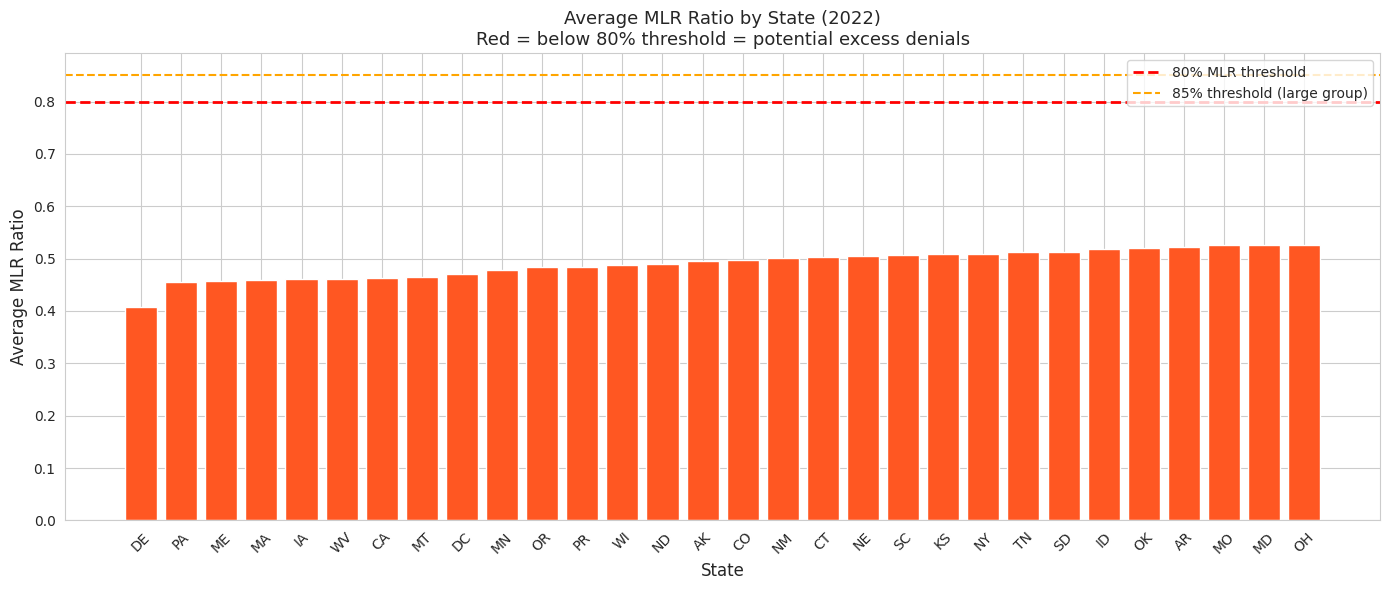

✅ Saved: Q1_05_mlr_by_state.png


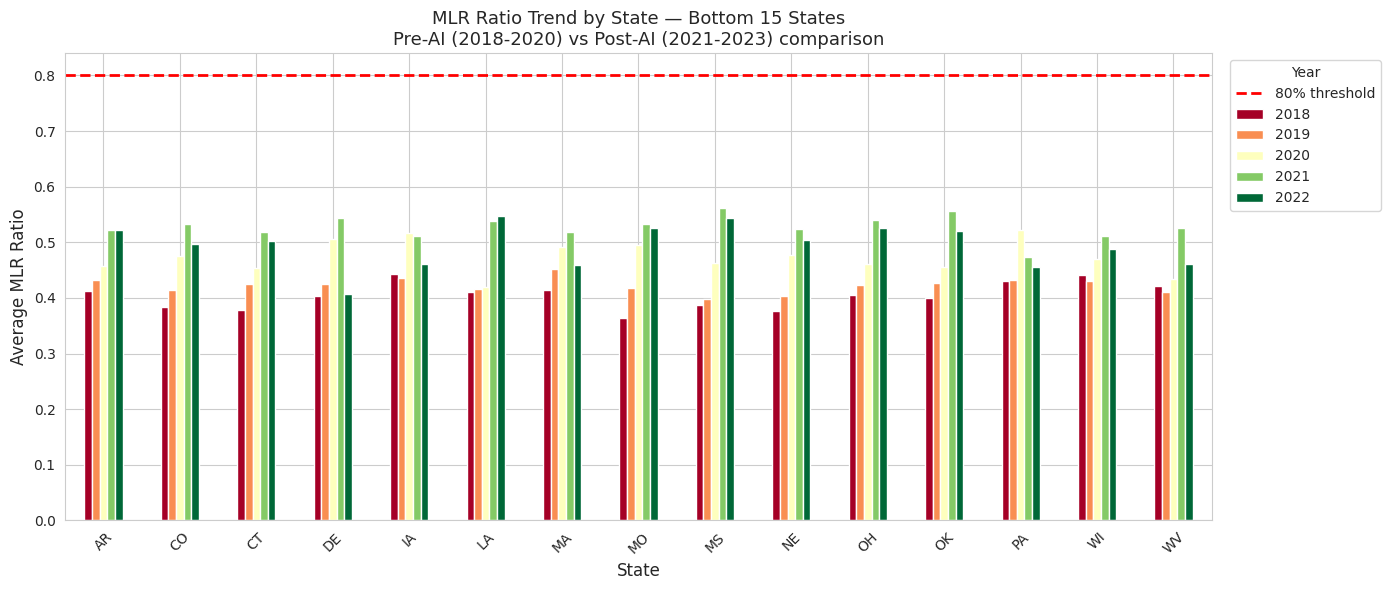

✅ Saved: Q1_06_mlr_state_year_trend.png

✅ Done — 20 total plots saved to Drive!


In [ ]:
# Combine both ID columns into one
mlr_part3["template_id"] = pd.to_numeric(
    mlr_part3["MR_SUBMISSION_TEMPLATE_ID"].fillna(
    mlr_part3["mr_submission_template_id"]), errors="coerce")

print("Non-null template IDs in Part3:", mlr_part3["template_id"].notna().sum())
print("Sample IDs:", mlr_part3["template_id"].dropna().unique()[:5])

# Rebuild ratio subset
mlr_ratio = mlr_part3[mlr_part3["MLR_RATIO"].notna()].copy()

# Merge on combined ID
mlr_geo = mlr_ratio.merge(
    header_clean[["mr_submission_template_id","_year",
                  "business_state","company_name"]]
    .rename(columns={"mr_submission_template_id":"template_id"}),
    on=["template_id","_year"],
    how="left"
)
print(f"\nMerged: {mlr_geo.shape}")
print(f"Rows with state: {mlr_geo['business_state'].notna().sum():,}")

# State-level summary
state_mlr = (
    mlr_geo[
        mlr_geo["MLR_RATIO"].between(0,2) &
        mlr_geo["business_state"].notna()
    ]
    .groupby(["business_state","_year"])
    .agg(
        avg_mlr     = ("MLR_RATIO","mean"),
        median_mlr  = ("MLR_RATIO","median"),
        issuers     = ("company_name","nunique"),
        below_80pct = ("MLR_RATIO", lambda x: (x < 0.80).sum())
    )
    .reset_index()
    .rename(columns={"business_state":"STATE"})
)
print(f"State-MLR table: {state_mlr.shape}")
latest_year = state_mlr["_year"].max()
print(f"\nTop 10 lowest MLR states ({latest_year}):")
print(state_mlr[state_mlr["_year"]==latest_year]
      .sort_values("avg_mlr").head(10)
      [["STATE","avg_mlr","below_80pct","issuers"]].to_string())

# ── PLOT 5: MLR by State
plot_states = (state_mlr[state_mlr["_year"]==latest_year]
               .sort_values("avg_mlr").head(30))
fig, ax = plt.subplots(figsize=(14,6))
colors = ["#FF5722" if v < 0.80 else "#2196F3"
          for v in plot_states["avg_mlr"]]
ax.bar(plot_states["STATE"], plot_states["avg_mlr"],
       color=colors, edgecolor="white")
ax.axhline(0.80, color="red", linestyle="--", lw=2, label="80% MLR threshold")
ax.axhline(0.85, color="orange", linestyle="--", lw=1.5,
           label="85% threshold (large group)")
ax.set_xlabel("State", fontsize=12)
ax.set_ylabel("Average MLR Ratio", fontsize=12)
ax.set_title(f"Average MLR Ratio by State ({latest_year})\n"
             "Red = below 80% threshold = potential excess denials", fontsize=13)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Datasets/EDA Plots/Q1_05_mlr_by_state.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: Q1_05_mlr_by_state.png")

# ── PLOT 6: MLR trend bottom 15 states
bottom_states = (state_mlr.groupby("STATE")["avg_mlr"]
                 .mean().sort_values().head(15).index.tolist())
pivot = (state_mlr[state_mlr["STATE"].isin(bottom_states)]
         .pivot_table(index="STATE", columns="_year",
                      values="avg_mlr", aggfunc="mean"))
fig, ax = plt.subplots(figsize=(14,6))
pivot.plot(kind="bar", ax=ax, colormap="RdYlGn", edgecolor="white")
ax.axhline(0.80, color="red", linestyle="--", lw=2, label="80% threshold")
ax.set_xlabel("State", fontsize=12)
ax.set_ylabel("Average MLR Ratio", fontsize=12)
ax.set_title("MLR Ratio Trend by State — Bottom 15 States\n"
             "Pre-AI (2018-2020) vs Post-AI (2021-2023) comparison", fontsize=13)
ax.legend(title="Year", bbox_to_anchor=(1.01,1), loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Datasets/EDA Plots/Q1_06_mlr_state_year_trend.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: Q1_06_mlr_state_year_trend.png")
print("\n✅ Done — 20 total plots saved to Drive!")